# Chapter 12

Add your content here.

Starting Training... Watch for the gap between Train and Test accuracy.
Step 0: Train Acc=0.01, Test Acc=0.01
Step 1000: Train Acc=1.00, Test Acc=0.24
Step 2000: Train Acc=1.00, Test Acc=0.99
Step 3000: Train Acc=1.00, Test Acc=1.00
Step 4000: Train Acc=1.00, Test Acc=1.00


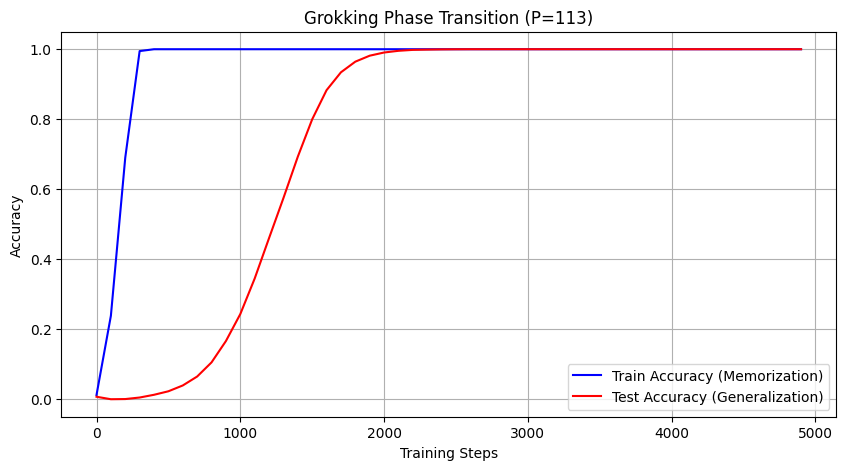

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURATION ---
P = 113          # Prime number for modulo
TRAIN_RATIO = 0.5 # We only show 50% of the data. It must infer the rest.
HIDDEN_DIM = 128
LR = 1e-3
WEIGHT_DECAY = 1.0 # High weight decay forces the "Phase Transition"
STEPS = 5000

# --- 2. DATA GENERATION ---
# We want the model to learn: Input (a, b) -> Output (a + b) % P
data = []
for i in range(P):
    for j in range(P):
        target = (i + j) % P
        data.append([i, j, target])

data = torch.tensor(data, dtype=torch.long)
# Shuffle and Split
perm = torch.randperm(len(data))
data = data[perm]
split = int(len(data) * TRAIN_RATIO)

train_data = data[:split] # The "Cramming" set
test_data = data[split:]  # The "Understanding" set

# --- 3. MODEL DEFINITION ---
class GrokkingNet(nn.Module):
    def __init__(self, p, dim):
        super().__init__()
        self.embed = nn.Embedding(p, dim)
        self.fc = nn.Sequential(
            nn.Linear(2 * dim, dim),
            nn.ReLU(),
            nn.Linear(dim, p) # Outputs Logits
        )
    
    def forward(self, x):
        # Embed inputs a and b
        a = self.embed(x[:, 0])
        b = self.embed(x[:, 1])
        # Concatenate and pass through network
        combined = torch.cat([a, b], dim=1)
        return self.fc(combined)

# --- 4. TRAINING LOOP ---
model = GrokkingNet(P, HIDDEN_DIM)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

train_accs = []
test_accs = []
steps = []

print("Starting Training... Watch for the gap between Train and Test accuracy.")

for step in range(STEPS):
    model.train()
    # Forward Pass
    logits = model(train_data[:, :2])
    loss = criterion(logits, train_data[:, 2])
    
    # Backward Pass (Gradient Descent)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Logging every 100 steps
    if step % 100 == 0:
        with torch.no_grad():
            model.eval()
            # Calculate Accuracy
            tr_preds = model(train_data[:, :2]).argmax(dim=1)
            tr_acc = (tr_preds == train_data[:, 2]).float().mean()
            
            te_preds = model(test_data[:, :2]).argmax(dim=1)
            te_acc = (te_preds == test_data[:, 2]).float().mean()
            
            train_accs.append(tr_acc.item())
            test_accs.append(te_acc.item())
            steps.append(step)
            
            if step % 1000 == 0:
                print(f"Step {step}: Train Acc={tr_acc:.2f}, Test Acc={te_acc:.2f}")

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 5))
plt.plot(steps, train_accs, label='Train Accuracy (Memorization)', color='blue')
plt.plot(steps, test_accs, label='Test Accuracy (Generalization)', color='red')
plt.xlabel('Training Steps')
plt.ylabel('Accuracy')
plt.title(f'Grokking Phase Transition (P={P})')
plt.legend()
plt.grid(True)
plt.show()